In [ ]:
import pandas as pd

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

# =========================================================
# CONFIG
# =========================================================

BT_RUN_ID = "ms_edge_9664290763"
BT_RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/runs/run_id={BT_RUN_ID}"

# =========================================================
# LOAD FILES
# =========================================================

router_trades = read_parquet_s3(f"{BT_RUN_ROOT}/router_trades.parquet")
trades = read_parquet_s3(f"{BT_RUN_ROOT}/trades.parquet")
res = read_parquet_s3(f"{BT_RUN_ROOT}/res.parquet")

router_trades["timestamp"] = pd.to_datetime(router_trades["timestamp"], utc=True)
router_trades["day"] = pd.to_datetime(router_trades["day"], utc=True)

trades["timestamp"] = pd.to_datetime(trades["timestamp"], utc=True)
trades["day"] = pd.to_datetime(trades["day"], utc=True)

print("router_trades shape:", router_trades.shape)
print("trades shape:", trades.shape)
print("res shape:", res.shape)

# =========================================================
# 1) ROUTER PICK COUNTS
# =========================================================

print("\n=== router_trades['router_pick'].value_counts() ===\n")
print(router_trades["router_pick"].value_counts())

# =========================================================
# 2) MEAN PNL BY ROUTER PICK
# =========================================================

print("\n=== router_trades.groupby('router_pick')['pnl_net_bps'].mean() ===\n")
print(router_trades.groupby("router_pick")["pnl_net_bps"].mean())

# =========================================================
# 3) EXTRA CHECKS (useful)
# =========================================================

print("\n=== n_trades by router_pick ===\n")
print(router_trades.groupby("router_pick").size())

print("\n=== n_days by router_pick ===\n")
print(router_trades.groupby("router_pick")["day"].nunique())

print("\n=== overall router EV ===\n")
print(router_trades["pnl_net_bps"].mean())

print("\n=== baseline trades by config ===\n")
print(trades.groupby("config")["pnl_net_bps"].agg(["count", "mean"]))

print("\n=== res preview ===\n")
display(res.sort_values(["month", "config"]).reset_index(drop=True))

In [5]:
import pandas as pd
import numpy as np

from ml_bot.backtest.lib.io_s3 import read_parquet_s3
from ml_bot.backtest.lib.bootstrap import bootstrap_block_by_day

# =========================================================
# CONFIG
# =========================================================

BT_RUN_ID = "ms_edge_9664290763"
BT_RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/runs/run_id={BT_RUN_ID}"

DATASET_PATH = "s3://tradebot-config-tokyo/research/ms_edge/ml/stageb_dataset.parquet"

ML_HIGH_RUN_ID = "stageb_ml_high_78fac97649"
ML_HIGH_RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={ML_HIGH_RUN_ID}"

BO_CFG = "BO | rw>-15 | gate=T60>0 | 60_if_neg_else_180"
MR_CFG = "MR | rw>-15 | gate=T60>0 | 60_if_neg_else_180"

THRESHOLD = 0.70

# =========================================================
# HELPERS
# =========================================================

def summarize(name: str, df: pd.DataFrame, pnl_col: str = "pnl_net_bps") -> dict:
    x = df[pnl_col].dropna().to_numpy(dtype="float64")
    if len(x) == 0:
        return {
            "strategy": name,
            "n_trades": 0,
            "n_days": 0,
            "EV_bps": np.nan,
            "CI_blk_lo": np.nan,
            "CI_blk_hi": np.nan,
            "avg_size": np.nan,
        }

    ci_blk = bootstrap_block_by_day(
        df.rename(columns={pnl_col: "pnl_used"}),
        value_col="pnl_used",
        day_col="day",
        n_boot=2000,
        seed=7,
    )

    return {
        "strategy": name,
        "n_trades": int(len(x)),
        "n_days": int(df["day"].nunique()),
        "EV_bps": float(np.mean(x)),
        "CI_blk_lo": float(ci_blk[0]),
        "CI_blk_hi": float(ci_blk[1]),
        "avg_size": float(df["size_mult"].mean()) if "size_mult" in df.columns else 1.0,
    }

def map_regime3(v: str) -> str:
    if v in ("b0", "b1"):
        return "low"
    if v == "b2":
        return "mid"
    if v in ("b3", "b4"):
        return "high"
    return "other"
    
def size_multiplier(score: float, vol_regime3: str) -> float:

    if vol_regime3 != "high":
        return 1.0

    if score >= 0.83:
        return 1.7

    elif score >= 0.79:
        return 1.1

    elif score >= 0.73:
        return 0.9

    elif score >= 0.70:
        return 0.7

    else:
        return 0.0

# =========================================================
# LOAD BASELINE ROUTER TRADES
# =========================================================

router_trades = read_parquet_s3(f"{BT_RUN_ROOT}/router_trades.parquet")
router_trades["timestamp"] = pd.to_datetime(router_trades["timestamp"], utc=True)
router_trades["day"] = pd.to_datetime(router_trades["day"], utc=True)

# =========================================================
# LOAD DATASET META (TEST ONLY)
# =========================================================

ds = read_parquet_s3(DATASET_PATH)
ds["timestamp"] = pd.to_datetime(ds["timestamp"], utc=True)
ds = ds.loc[ds["split"] == "test"].copy()
ds["vol_regime3"] = ds["vol_bucket"].map(map_regime3)

meta = ds[["timestamp", "router_branch", "vol_bucket", "vol_regime3"]].drop_duplicates()

# =========================================================
# LOAD ML HIGH TEST SCORES
# =========================================================

sc_test = read_parquet_s3(f"{ML_HIGH_RUN_ROOT}/scored_test.parquet")
sc_test["timestamp"] = pd.to_datetime(sc_test["timestamp"], utc=True)

scores = sc_test[["timestamp", "score"]].drop_duplicates()

# =========================================================
# MERGE EVERYTHING
# =========================================================

rt = router_trades.merge(meta, on="timestamp", how="left")
rt = rt.merge(scores, on="timestamp", how="left")

# =========================================================
# BUILD STRATEGIES
# =========================================================

# 1) baseline router
baseline = rt.copy()
baseline["size_mult"] = 1.0
baseline["pnl_sized_bps"] = baseline["pnl_net_bps"] * baseline["size_mult"]

# 2) threshold only
thr_only = rt.copy()
thr_only["size_mult"] = 1.0

mask_drop = (
    (thr_only["router_pick"] == BO_CFG) &
    (thr_only["vol_regime3"] == "high") &
    (thr_only["score"] < THRESHOLD)
)

thr_only = thr_only.loc[~mask_drop].copy()
thr_only["size_mult"] = 1.0
thr_only["pnl_sized_bps"] = thr_only["pnl_net_bps"]

# 3) threshold + sizing
sized = rt.copy()
sized["size_mult"] = sized.apply(
    lambda r: size_multiplier(r["score"], r["vol_regime3"])
    if r["router_pick"] == BO_CFG else 1.0,
    axis=1,
)

# keep MR always, keep BO low always, keep BO high only if size>0
keep_mask = (
    (sized["router_pick"] == MR_CFG) |
    ((sized["router_pick"] == BO_CFG) & (sized["vol_regime3"] != "high")) |
    ((sized["router_pick"] == BO_CFG) & (sized["vol_regime3"] == "high") & (sized["size_mult"] > 0))
)

sized = sized.loc[keep_mask].copy()
sized["pnl_sized_bps"] = sized["pnl_net_bps"] * sized["size_mult"]

# =========================================================
# OUTPUT TABLE
# =========================================================

rows = []
rows.append(summarize("ROUTER_baseline", baseline, pnl_col="pnl_net_bps"))
rows.append(summarize("ROUTER_plus_high_threshold", thr_only, pnl_col="pnl_net_bps"))
rows.append(summarize("ROUTER_plus_high_threshold_and_sizing", sized, pnl_col="pnl_sized_bps"))

res = pd.DataFrame(rows)

print("\n=== BACKTEST PRODUCTION CANDIDATE ===\n")
print(res.to_string(index=False))

# =========================================================
# OPTIONAL: breakdown of sized strategy
# =========================================================

print("\n=== SIZE DISTRIBUTION (sized strategy) ===\n")
print(sized["size_mult"].value_counts().sort_index())

print("\n=== EV BY SUBSET (sized strategy) ===\n")
subset = (
    sized.groupby(["router_pick", "vol_regime3"])
    .agg(
        n=("pnl_sized_bps", "count"),
        ev_bps=("pnl_sized_bps", "mean"),
        avg_size=("size_mult", "mean"),
    )
    .reset_index()
)
print(subset.to_string(index=False))


=== BACKTEST PRODUCTION CANDIDATE ===

                             strategy  n_trades  n_days   EV_bps  CI_blk_lo  CI_blk_hi  avg_size
                      ROUTER_baseline       774     103 4.786846   3.129848   6.367889  1.000000
           ROUTER_plus_high_threshold       732     103 4.762248   2.984702   6.457757  1.000000
ROUTER_plus_high_threshold_and_sizing       732     103 5.469166   3.370995   7.436962  1.082514

=== SIZE DISTRIBUTION (sized strategy) ===

size_mult
0.7     21
0.9     64
1.0    438
1.1    122
1.7     87
Name: count, dtype: int64

=== EV BY SUBSET (sized strategy) ===

                                  router_pick vol_regime3   n    ev_bps  avg_size
BO | rw>-15 | gate=T60>0 | 60_if_neg_else_180        high 294  8.038921  1.205442
BO | rw>-15 | gate=T60>0 | 60_if_neg_else_180         low 228  2.939331  1.000000
BO | rw>-15 | gate=T60>0 | 60_if_neg_else_180         mid  93  4.097254  1.000000
MR | rw>-15 | gate=T60>0 | 60_if_neg_else_180        high  60  3.013

rows: 398
global EV: 5.5959618481386215

=== CAPITAL ALLOCATION BY SCORE QUANTILE ===

 q  n   ev_bps  p50_bps   p95_bps  score_min  score_max  ev_ratio_vs_global  size_suggested
 0 80 9.333517 8.326250 44.630950   0.832770   0.871595            1.667902        1.667902
 1 79 4.244649 3.700849 25.670789   0.815107   0.832770            0.758520        0.758520
 2 80 3.236427 2.146379 25.301411   0.790991   0.815024            0.578351        0.578351
 3 79 6.252257 5.991946 26.667535   0.734245   0.789880            1.117280        1.117280
 4 80 4.904271 4.463326 24.778872   0.489928   0.734241            0.876395        0.876395


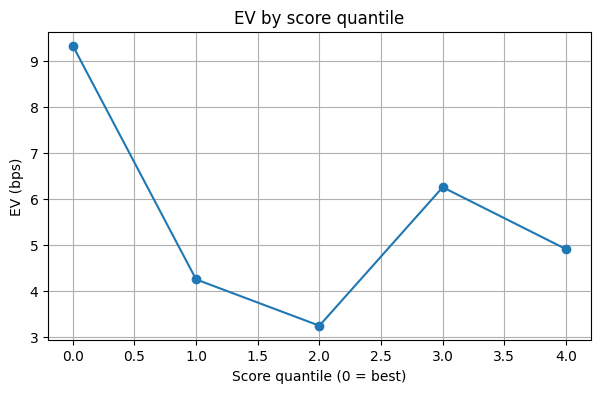

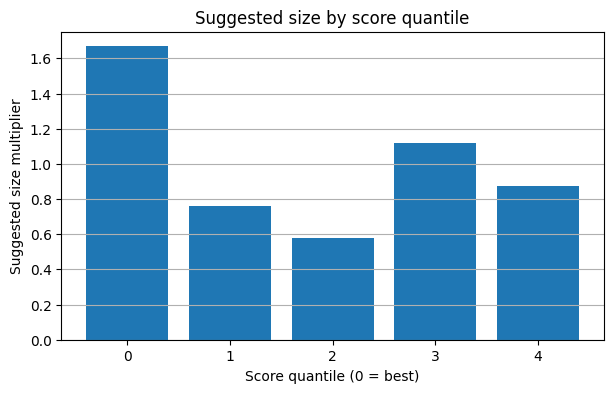

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

# =========================================================
# CONFIG
# =========================================================

RUN_ID = "stageb_ml_high_78fac97649"
RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={RUN_ID}"

N_BUCKETS = 5   # tu peux tester 4, 5 ou 6

# =========================================================
# LOAD DATA
# =========================================================

df = read_parquet_s3(f"{RUN_ROOT}/scored_test.parquet")
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)

df = df.dropna(subset=["score", "pnl_net_bps"]).copy()

print("rows:", len(df))

global_ev = float(df["pnl_net_bps"].mean())
print("global EV:", global_ev)

# =========================================================
# BUILD SCORE QUANTILES
# Highest score bucket = q0
# =========================================================

df["q"] = pd.qcut(
    df["score"].rank(method="first"),
    N_BUCKETS,
    labels=False
)
df["q"] = (N_BUCKETS - 1) - df["q"]

# =========================================================
# EV BY QUANTILE
# =========================================================

qtab = (
    df.groupby("q")
      .agg(
          n=("pnl_net_bps", "count"),
          ev_bps=("pnl_net_bps", "mean"),
          p50_bps=("pnl_net_bps", "median"),
          p95_bps=("pnl_net_bps", lambda s: np.quantile(s, 0.95)),
          score_min=("score", "min"),
          score_max=("score", "max"),
      )
      .reset_index()
      .sort_values("q")
)

# relative edge vs global
qtab["ev_ratio_vs_global"] = qtab["ev_bps"] / global_ev

# raw suggested size = clipped ratio
# conservative clip to avoid insane leverage
qtab["size_suggested"] = qtab["ev_ratio_vs_global"].clip(lower=0.0, upper=2.0)

print("\n=== CAPITAL ALLOCATION BY SCORE QUANTILE ===\n")
print(qtab.to_string(index=False))

# =========================================================
# PLOT
# =========================================================

plt.figure(figsize=(7,4))
plt.plot(qtab["q"], qtab["ev_bps"], marker="o")
plt.xlabel("Score quantile (0 = best)")
plt.ylabel("EV (bps)")
plt.title("EV by score quantile")
plt.grid(True)
plt.show()

plt.figure(figsize=(7,4))
plt.bar(qtab["q"].astype(str), qtab["size_suggested"])
plt.xlabel("Score quantile (0 = best)")
plt.ylabel("Suggested size multiplier")
plt.title("Suggested size by score quantile")
plt.grid(True, axis="y")
plt.show()

In [ ]:
import pandas as pd
import numpy as np

from ml_bot.backtest.lib.io_s3 import read_parquet_s3

# =========================================================
# CONFIG
# =========================================================

RUN_ID = "ms_edge_9664290763"
RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/runs/run_id={RUN_ID}"

ML_RUN_ID = "stageb_ml_high_78fac97649"
ML_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={ML_RUN_ID}"

# =========================================================
# LOAD DATA
# =========================================================

router_trades = read_parquet_s3(f"{RUN_ROOT}/router_trades.parquet")
scores = read_parquet_s3(f"{ML_ROOT}/scored_test.parquet")

router_trades["timestamp"] = pd.to_datetime(router_trades["timestamp"], utc=True)
router_trades["day"] = pd.to_datetime(router_trades["day"], utc=True)
scores["timestamp"] = pd.to_datetime(scores["timestamp"], utc=True)

df = router_trades.merge(
    scores[["timestamp", "score"]],
    on="timestamp",
    how="left"
)

# =========================================================
# VOL REGIME
# =========================================================

dataset = read_parquet_s3(
    "s3://tradebot-config-tokyo/research/ms_edge/ml/stageb_dataset.parquet"
)

dataset["timestamp"] = pd.to_datetime(dataset["timestamp"], utc=True)

def map_regime3(v):
    if v in ("b0", "b1"):
        return "low"
    if v == "b2":
        return "mid"
    if v in ("b3", "b4"):
        return "high"
    return "other"

dataset["vol_regime3"] = dataset["vol_bucket"].map(map_regime3)

df = df.merge(
    dataset[["timestamp", "vol_regime3"]],
    on="timestamp",
    how="left"
)

# =========================================================
# SIZE FUNCTION
# =========================================================

def size_multiplier(score, vol_regime3):

    if vol_regime3 != "high":
        return 1.0

    if score >= 0.83:
        return 1.3

    elif score >= 0.79:
        return 1.1

    elif score >= 0.73:
        return 0.9

    elif score >= 0.70:
        return 0.8

    else:
        return 0.0
    
df["size_mult"] = df.apply(
    lambda r: size_multiplier(r["score"], r["vol_regime3"]),
    axis=1
)

df["pnl_sized"] = df["pnl_net_bps"] * df["size_mult"]

# =========================================================
# DAILY PNL
# =========================================================

daily = (
    df.groupby("day")
    .agg(
        baseline=("pnl_net_bps", "mean"),
        ml=("pnl_sized", "mean")
    )
)

daily["improvement"] = daily["ml"] - daily["baseline"]

print("\n=== DAILY EV ===\n")
print(daily.describe())

# =========================================================
# WORST DAYS
# =========================================================

worst = daily.sort_values("baseline").head(10)

print("\n=== 10 WORST BASELINE DAYS ===\n")
print(worst)

print(
    "\nMean improvement on worst days:",
    worst["improvement"].mean()
)

# =========================================================
# BEST DAYS
# =========================================================

best = daily.sort_values("baseline").tail(10)

print("\n=== 10 BEST BASELINE DAYS ===\n")
print(best)

print(
    "\nMean improvement on best days:",
    best["improvement"].mean()
)


=== DAILY EV ===

         baseline          ml  improvement
count  103.000000  103.000000   103.000000
mean     4.263414    4.268592     0.005177
std      8.459373    9.692940     2.702109
min    -16.130285  -27.737000   -12.378667
25%     -1.144619   -2.087701     0.000000
50%      4.142465    4.075027     0.000000
75%     10.138181    9.939093     0.037594
max     28.113679   43.923940    16.456064

=== 10 WORST BASELINE DAYS ===

                            baseline         ml  improvement
day                                                         
2025-09-17 00:00:00+00:00 -16.130285 -17.743314    -1.613029
2025-10-29 00:00:00+00:00 -15.358334 -27.737000   -12.378667
2025-07-24 00:00:00+00:00 -14.892104 -14.892104     0.000000
2025-07-07 00:00:00+00:00 -10.245110 -10.245110     0.000000
2025-08-09 00:00:00+00:00  -9.957189  -9.957189     0.000000
2025-10-09 00:00:00+00:00  -9.703180 -12.683125    -2.979946
2025-05-14 00:00:00+00:00  -8.352131  -8.352131     0.000000
2025-06-11 0

In [12]:
import pandas as pd
import numpy as np

from ml_bot.backtest.lib.io_s3 import read_parquet_s3
from ml_bot.backtest.lib.bootstrap import bootstrap_block_by_day

# =========================================================
# CONFIG
# =========================================================

BT_RUN_ID = "ms_edge_9664290763"
BT_RUN_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/runs/run_id={BT_RUN_ID}"

ML_RUN_ID = "stageb_ml_high_78fac97649"
ML_ROOT = f"s3://tradebot-config-tokyo/research/ms_edge/ml/runs/run_id={ML_RUN_ID}"

DATASET_PATH = "s3://tradebot-config-tokyo/research/ms_edge/ml/stageb_dataset.parquet"

BO_CFG = "BO | rw>-15 | gate=T60>0 | 60_if_neg_else_180"
MR_CFG = "MR | rw>-15 | gate=T60>0 | 60_if_neg_else_180"

# =========================================================
# HELPERS
# =========================================================

def map_regime3(v):
    if v in ("b0", "b1"):
        return "low"
    if v == "b2":
        return "mid"
    if v in ("b3", "b4"):
        return "high"
    return "other"

def ml_size_multiplier(score: float, vol_regime3: str) -> float:
    """
    Current production-candidate ML allocator.
    """
    if vol_regime3 != "high":
        return 1.0

    if pd.isna(score):
        return 1.0

    if score >= 0.83:
        return 1.3
    elif score >= 0.79:
        return 1.1
    elif score >= 0.73:
        return 0.9
    elif score >= 0.70:
        return 0.8
    else:
        return 0.0

def drawdown_multiplier(day_pnl_running_bps: float) -> float:
    """
    Drawdown-aware risk governor.
    IMPORTANT:
    uses day pnl BEFORE current trade, not after.
    """
    if day_pnl_running_bps >= 0:
        return 1.0
    elif day_pnl_running_bps > -5:
        return 0.9
    elif day_pnl_running_bps > -10:
        return 0.75
    else:
        return 0.5

def summarize(name: str, df: pd.DataFrame, pnl_col: str) -> dict:
    x = df[pnl_col].dropna().to_numpy(dtype="float64")
    if len(x) == 0:
        return {
            "strategy": name,
            "n_trades": 0,
            "n_days": 0,
            "EV_bps": np.nan,
            "CI_blk_lo": np.nan,
            "CI_blk_hi": np.nan,
            "avg_size": np.nan,
        }

    tmp = df.copy().rename(columns={pnl_col: "pnl_used"})
    ci_blk = bootstrap_block_by_day(
        tmp,
        value_col="pnl_used",
        day_col="day",
        n_boot=2000,
        seed=7,
    )

    return {
        "strategy": name,
        "n_trades": int(len(x)),
        "n_days": int(df["day"].nunique()),
        "EV_bps": float(np.mean(x)),
        "CI_blk_lo": float(ci_blk[0]),
        "CI_blk_hi": float(ci_blk[1]),
        "avg_size": float(df["size_final"].mean()) if "size_final" in df.columns else 1.0,
    }

# =========================================================
# LOAD DATA
# =========================================================

router_trades = read_parquet_s3(f"{BT_RUN_ROOT}/router_trades.parquet")
router_trades["timestamp"] = pd.to_datetime(router_trades["timestamp"], utc=True)
router_trades["day"] = pd.to_datetime(router_trades["day"], utc=True)

scores = read_parquet_s3(f"{ML_ROOT}/scored_test.parquet")
scores["timestamp"] = pd.to_datetime(scores["timestamp"], utc=True)

dataset = read_parquet_s3(DATASET_PATH)
dataset["timestamp"] = pd.to_datetime(dataset["timestamp"], utc=True)
dataset = dataset.loc[dataset["split"] == "test"].copy()
dataset["vol_regime3"] = dataset["vol_bucket"].map(map_regime3)

meta = dataset[["timestamp", "vol_bucket", "vol_regime3"]].drop_duplicates()

# merge
df = router_trades.merge(
    scores[["timestamp", "score"]],
    on="timestamp",
    how="left"
).merge(
    meta,
    on="timestamp",
    how="left"
)

df = df.sort_values(["day", "timestamp"]).reset_index(drop=True)

print("merged rows:", len(df))
print("days:", df["day"].nunique())

# =========================================================
# BASELINE + ML SIZE ONLY
# =========================================================

# baseline
df["pnl_baseline"] = df["pnl_net_bps"]

# ml allocator only
df["size_ml"] = df.apply(
    lambda r: ml_size_multiplier(r["score"], r["vol_regime3"]),
    axis=1
)

# note:
# size=0 means skip trade
df["pnl_ml_only"] = df["pnl_net_bps"] * df["size_ml"]

# =========================================================
# DRAWDOWN-AWARE SEQUENTIAL BACKTEST
# =========================================================

rows = []

for day, g in df.groupby("day", sort=True):
    g = g.sort_values("timestamp").copy()

    running_pnl_before = 0.0
    out_day = []

    for _, r in g.iterrows():
        dd_mult = drawdown_multiplier(running_pnl_before)

        # final size uses ml allocator first, then governor
        size_final = float(r["size_ml"]) * float(dd_mult)

        pnl_final = float(r["pnl_net_bps"]) * size_final

        out_day.append({
            **r.to_dict(),
            "day_pnl_before_trade": running_pnl_before,
            "dd_mult": dd_mult,
            "size_final": size_final,
            "pnl_final": pnl_final,
        })

        # update with realized pnl AFTER trade
        running_pnl_before += pnl_final

    rows.extend(out_day)

seq = pd.DataFrame(rows)

# =========================================================
# FILTERED VIEWS
# =========================================================

# baseline keeps all trades notionally at size 1
baseline = seq.copy()
baseline["size_final"] = 1.0

# ml-only policy: keep trades where size_ml > 0
ml_only = seq.loc[seq["size_ml"] > 0].copy()
ml_only["size_final"] = ml_only["size_ml"]

# dd-aware policy: keep trades where final size > 0
dd_aware = seq.loc[seq["size_final"] > 0].copy()

# =========================================================
# SUMMARY TABLE
# =========================================================

res = pd.DataFrame([
    summarize("ROUTER_baseline", baseline, pnl_col="pnl_baseline"),
    summarize("ROUTER_plus_ML_sizing_only", ml_only, pnl_col="pnl_ml_only"),
    summarize("ROUTER_plus_ML_sizing_and_DD", dd_aware, pnl_col="pnl_final"),
])

print("\n=== DRAWDOWN-AWARE BACKTEST (SEQUENTIAL, NO LOOKAHEAD) ===\n")
print(res.to_string(index=False))

# =========================================================
# DAILY ANALYSIS
# =========================================================

daily = (
    seq.groupby("day")
    .agg(
        baseline=("pnl_baseline", "mean"),
        ml_only=("pnl_ml_only", "mean"),
        dd_aware=("pnl_final", "mean"),
    )
)

daily["impr_ml_only"] = daily["ml_only"] - daily["baseline"]
daily["impr_dd_aware"] = daily["dd_aware"] - daily["baseline"]

print("\n=== DAILY EV SUMMARY ===\n")
print(daily.describe())

# worst days by baseline
worst = daily.sort_values("baseline").head(10)

print("\n=== 10 WORST BASELINE DAYS ===\n")
print(worst)

print("\nMean improvement on worst days:")
print("ml_only :", worst["impr_ml_only"].mean())
print("dd_aware:", worst["impr_dd_aware"].mean())

# best days by baseline
best = daily.sort_values("baseline", ascending=False).head(10)

print("\n=== 10 BEST BASELINE DAYS ===\n")
print(best)

print("\nMean improvement on best days:")
print("ml_only :", best["impr_ml_only"].mean())
print("dd_aware:", best["impr_dd_aware"].mean())

# =========================================================
# EXTRA DIAGNOSTICS
# =========================================================

print("\n=== SIZE DISTRIBUTION: ML ONLY ===\n")
print(ml_only["size_ml"].value_counts().sort_index())

print("\n=== SIZE DISTRIBUTION: DD-AWARE FINAL ===\n")
print(dd_aware["size_final"].round(4).value_counts().sort_index())

subset = (
    dd_aware.groupby(["router_pick", "vol_regime3"])
    .agg(
        n=("pnl_final", "count"),
        ev_bps=("pnl_final", "mean"),
        avg_size=("size_final", "mean"),
    )
    .reset_index()
)

print("\n=== EV BY SUBSET (DD-AWARE) ===\n")
print(subset.to_string(index=False))

merged rows: 774
days: 103

=== DRAWDOWN-AWARE BACKTEST (SEQUENTIAL, NO LOOKAHEAD) ===

                    strategy  n_trades  n_days   EV_bps  CI_blk_lo  CI_blk_hi  avg_size
             ROUTER_baseline       774     103 4.786846   3.129848   6.367889  1.000000
  ROUTER_plus_ML_sizing_only       732     103 5.058888   3.135362   6.880205  1.037842
ROUTER_plus_ML_sizing_and_DD       732     103 5.002735   3.137674   6.818841  0.954481

=== DAILY EV SUMMARY ===

         baseline     ml_only    dd_aware  impr_ml_only  impr_dd_aware
count  103.000000  103.000000  103.000000    103.000000     103.000000
mean     4.263414    4.098623    4.121705     -0.164791      -0.141710
std      8.459373    8.881484    8.749472      1.544552       1.607576
min    -16.130285  -20.663476  -21.977010     -5.878490      -6.618677
25%     -1.144619   -2.087701   -1.861642     -0.014763      -0.367135
50%      4.142465    3.871153    3.422620      0.000000       0.000000
75%     10.138181    9.616807    9.4

In [13]:
baseline["month"] = baseline["timestamp"].dt.to_period("M")

monthly_baseline = (
    baseline.groupby("month")
    .agg(
        n_trades=("pnl_baseline", "count"),
        EV_bps=("pnl_baseline", "mean"),
        p50=("pnl_baseline", "median"),
        p95=("pnl_baseline", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

print("\n=== MONTHLY EV: BASELINE ===\n")
print(monthly_baseline)


=== MONTHLY EV: BASELINE ===

     month  n_trades    EV_bps       p50        p95
0  2025-05        12  6.963659  5.998290  35.002442
1  2025-06        40  3.143633  2.233171  20.437530
2  2025-07        53  6.110143  6.060819  22.068862
3  2025-08       213  4.385500  2.092092  28.723851
4  2025-09        66  4.755619  4.335543  24.571240
5  2025-10       390  4.933050  4.364062  27.672797


/var/folders/my/rlps7sd127bcnxcjs29ybzfm0000gn/T/ipykernel_77651/2116129690.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  baseline["month"] = baseline["timestamp"].dt.to_period("M")


In [14]:
ml_only["month"] = ml_only["timestamp"].dt.to_period("M")

monthly_ml_only = (
    ml_only.groupby("month")
    .agg(
        n_trades=("pnl_ml_only", "count"),
        EV_bps=("pnl_ml_only", "mean"),
        p50=("pnl_ml_only", "median"),
        p95=("pnl_ml_only", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

print("\n=== MONTHLY EV: ML SIZING ONLY ===\n")
print(monthly_ml_only)


=== MONTHLY EV: ML SIZING ONLY ===

     month  n_trades    EV_bps       p50        p95
0  2025-05        12  7.497479  5.918775  39.855599
1  2025-06        34  2.049553  0.483433  19.686789
2  2025-07        52  6.177799  5.689336  22.069184
3  2025-08       203  4.533609  1.882882  32.941396
4  2025-09        63  4.612876  3.899958  22.407031
5  2025-10       368  5.465412  4.532049  30.526978


/var/folders/my/rlps7sd127bcnxcjs29ybzfm0000gn/T/ipykernel_77651/1112197612.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ml_only["month"] = ml_only["timestamp"].dt.to_period("M")


In [15]:
dd_aware["month"] = dd_aware["timestamp"].dt.to_period("M")

monthly_dd = (
    dd_aware.groupby("month")
    .agg(
        n_trades=("pnl_final", "count"),
        EV_bps=("pnl_final", "mean"),
        p50=("pnl_final", "median"),
        p95=("pnl_final", lambda x: x.quantile(0.95)),
    )
    .reset_index()
)

print("\n=== MONTHLY EV: ML + DD GOVERNOR ===\n")
print(monthly_dd)


=== MONTHLY EV: ML + DD GOVERNOR ===

     month  n_trades    EV_bps       p50        p95
0  2025-05        12  7.702759  5.918775  39.855599
1  2025-06        34  1.966178  0.448203  18.905406
2  2025-07        52  6.072810  5.689336  22.069184
3  2025-08       203  4.641849  1.734759  32.929108
4  2025-09        63  4.605186  3.899958  22.407031
5  2025-10       368  5.311170  3.902673  28.699186


/var/folders/my/rlps7sd127bcnxcjs29ybzfm0000gn/T/ipykernel_77651/1557684757.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  dd_aware["month"] = dd_aware["timestamp"].dt.to_period("M")


In [16]:
monthly_compare = (
    baseline[["timestamp", "pnl_baseline"]]
    .merge(
        ml_only[["timestamp", "pnl_ml_only"]],
        on="timestamp",
        how="outer"
    )
    .merge(
        dd_aware[["timestamp", "pnl_final"]],
        on="timestamp",
        how="outer"
    )
)

monthly_compare["timestamp"] = pd.to_datetime(monthly_compare["timestamp"], utc=True)
monthly_compare["month"] = monthly_compare["timestamp"].dt.to_period("M")

monthly_compare = (
    monthly_compare.groupby("month")
    .agg(
        baseline_ev=("pnl_baseline", "mean"),
        ml_only_ev=("pnl_ml_only", "mean"),
        dd_aware_ev=("pnl_final", "mean"),
    )
    .reset_index()
)

print("\n=== MONTHLY EV COMPARISON ===\n")
print(monthly_compare)


=== MONTHLY EV COMPARISON ===

     month  baseline_ev  ml_only_ev  dd_aware_ev
0  2025-05     6.963659    7.497479     7.702759
1  2025-06     3.143633    2.049553     1.966178
2  2025-07     6.110143    6.177799     6.072810
3  2025-08     4.385500    4.533609     4.641849
4  2025-09     4.755619    4.612876     4.605186
5  2025-10     4.933050    5.465412     5.311170


/var/folders/my/rlps7sd127bcnxcjs29ybzfm0000gn/T/ipykernel_77651/1214894287.py:16: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  monthly_compare["month"] = monthly_compare["timestamp"].dt.to_period("M")


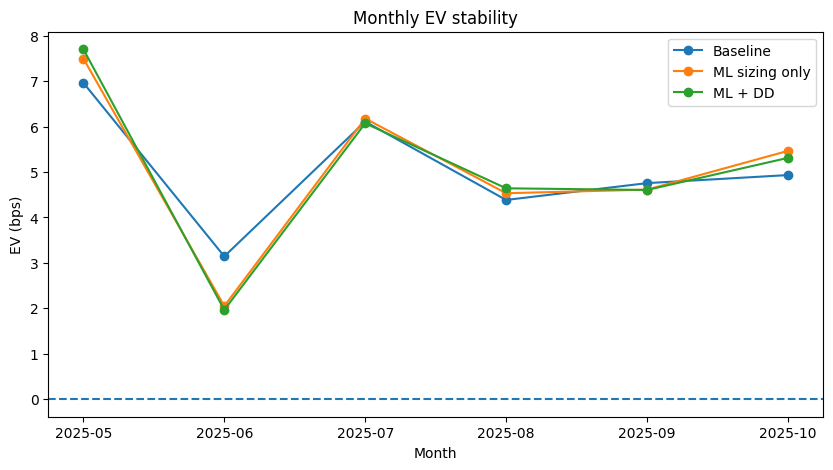

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

plt.plot(monthly_compare["month"].astype(str), monthly_compare["baseline_ev"], marker="o", label="Baseline")
plt.plot(monthly_compare["month"].astype(str), monthly_compare["ml_only_ev"], marker="o", label="ML sizing only")
plt.plot(monthly_compare["month"].astype(str), monthly_compare["dd_aware_ev"], marker="o", label="ML + DD")

plt.axhline(0, linestyle="--")
plt.title("Monthly EV stability")
plt.ylabel("EV (bps)")
plt.xlabel("Month")
plt.legend()
plt.show()

In [18]:
print(monthly_compare)

     month  baseline_ev  ml_only_ev  dd_aware_ev
0  2025-05     6.963659    7.497479     7.702759
1  2025-06     3.143633    2.049553     1.966178
2  2025-07     6.110143    6.177799     6.072810
3  2025-08     4.385500    4.533609     4.641849
4  2025-09     4.755619    4.612876     4.605186
5  2025-10     4.933050    5.465412     5.311170
